# Thermochemistry and the Partition Function
## Using DFT to Predict Isomer Stability: The Butene Case

---

## Why can't we just use electronic energy?

When you run a quantum chemistry calculation, the first number ORCA reports is the
**electronic energy**. This is the total energy of the electrons and nuclei at a fixed geometry,
at absolute zero, in vacuum. It is the most accurate number the calculation produces,
and also the most physically incomplete.

Real molecules at room temperature are not frozen at 0 K. They vibrate, rotate, and
translate. Their nuclei are not stationary. Even at absolute zero, quantum mechanics forbids a molecule
from sitting perfectly still: the **zero-point energy** (ZPE) is the irreducible minimum
vibrational energy that a molecule always carries, even at T = 0.

To predict which isomer is more stable, whether a reaction is spontaneous, or what a reaction rate is, we must
account for all of these contributions. That is the job of **statistical thermodynamics**.

---

## Partition functions and free energy

The bridge between quantum mechanics and thermodynamics is the **partition function**, q.
For a molecular system, we separate the total partition function into independent contributions:

$$q_{\text{total}} = q_t \cdot q_r \cdot q_v \cdot q_e$$

where the subscripts stand for **translational**, **rotational**, **vibrational**, and **electronic**.
From each partition function, we can derive the entropy S, internal energy U, and ultimately the
Gibbs free energy G using statistical mechanics.

The chain from an ORCA calculation to a thermodynamic quantity looks like this:

```
  E_el          (electronic energy, from SCF)
  + E_ZPE       (zero-point energy, from freq: ½Σhν)
  + E_vib(T)    (thermal vibrational population of excited modes)
  + E_rot(T)    (equipartition: ³⁄₂RT for nonlinear molecule)
  + E_trans(T)  (equipartition: ³⁄₂RT)
  ──────────────────────
  = U           (internal energy)
  + k_B T       (PV work term for ideal gas)
  ──────────────────────
  = H           (enthalpy)
  − T·S         (entropy penalty: translation + rotation + vibration)
  ──────────────────────
  = G           (Gibbs free energy)
```

**Why does this matter for isomers?** Three butene isomers (*gem*-, *trans*-, and *cis*-butene)
all have the formula C₄H₈. Their electronic energies differ by only a few kJ/mol. But their ZPE
corrections, vibrational entropies, and rotational entropies are all slightly different, because
their geometries and vibrational frequencies are different. Getting the isomer ordering right
requires including all of these contributions.

---

## The governing equations

The vibrational contribution to entropy, derived from the harmonic oscillator partition function, is:

$$S_v = R \sum_K \left[ \frac{\Theta_{v,K}/T}{e^{\Theta_{v,K}/T} - 1} - \ln\left(1 - e^{-\Theta_{v,K}/T}\right) \right]$$

where $\Theta_{v,K} = h\nu_K / k_B$ is the characteristic vibrational temperature of mode $K$.
The sum runs over all $3N - 6$ real vibrational modes (imaginary frequencies are excluded).

The vibrational contribution to internal energy (including ZPE) is:

$$E_v = R \sum_K \Theta_{v,K} \left[ \frac{1}{2} + \frac{1}{e^{\Theta_{v,K}/T} - 1} \right]$$

The translational and rotational contributions follow directly from the equipartition theorem
for an ideal gas ($\frac{3}{2}RT$ each for a nonlinear polyatomic). These are the dominant
entropy terms — translational entropy alone contributes ~47 kJ/mol to TS at 298 K.

Finally, $G = H - TS$ and:

$$\Delta G_{\text{rxn}} = \sum_{\text{products}} G_i - \sum_{\text{reactants}} G_j$$

---

## The system: butene isomers
![alt_text](butene.png)

These are computed at the **B3LYP-D4/def2-TZVP** level of theory.
Experimental values (from NIST) are +6.2 and +7.8 kJ/mol respectively.

---


## Glossary

| Term | Meaning |
|------|---------|
| **Partition function q** | Sum over all accessible states: q = Σ e^(−Eᵢ/kT) |
| **E_el** | Electronic energy from SCF — nuclei fixed, electrons optimised |
| **ZPE** | Zero-point energy: ½Σhν — minimum vibrational energy at 0 K |
| **Quasi-RRHO** | Rigid rotor / harmonic oscillator approximation (ORCA default) |
| **TS term** | Entropy × temperature — the free energy penalty for losing disorder |
| **G-E(el)** | The "thermal correction" — everything added to E_el to get G |
| **kJ/mol** | 1 Hartree = 2625.5 kJ/mol = 627.509 kcal/mol |
| **Imaginary frequency** | Negative in ORCA output (shown with minus sign) — saddle point |

---

---
# The ORCA Calculation

The output files you are working with were generated using the following input:
```
!B3LYP D4 DEF2-TZVP OPT FREQ
%FREQ TEMP 77, 298, 330, 450 END
* XYZFILE 0 1 gem-butene.xyz
```

| Keyword | Meaning |
|---------|---------|
| `B3LYP` | Hybrid DFT functional — exact exchange mixed with DFT correlation |
| `D4` | Grimme's D4 dispersion correction — captures van der Waals interactions |
| `DEF2-TZVP` | Triple-zeta basis set with polarisation functions |
| `OPT` | Optimise the geometry to the nearest energy minimum |
| `FREQ` | Compute vibrational frequencies at the optimised geometry — required for thermochemistry |
| `%FREQ TEMP ... END` | Compute thermodynamic functions at multiple temperatures from the same Hessian |

The order matters: ORCA runs `OPT` first, then `FREQ` at the optimised geometry.
Running `FREQ` at a non-optimised geometry gives meaningless thermochemistry.

If the calculation has already been run and you only want new temperatures, you can
skip the OPT FREQ entirely and just read the saved Hessian:
```
!PRINTTHERMOCHEM
%GEOM
  INHESSNAME "gem-butene.hess"
END
%FREQ TEMP 200, 250, 298, 350, 400 END
* XYZFILE 0 1 gem-butene.xyz
```

---
# Part 1: Setup

> **Just run these cells — no code to fill in.**

In [41]:
import subprocess, sys
subprocess.check_call([sys.executable, "-m", "pip", "install", "numpy", "matplotlib", "--quiet"])
print("All imports ready.")

All imports ready.


In [42]:
import numpy as np
import matplotlib.pyplot as plt
import re

EH_TO_KJ   = 2625.5    # 1 Hartree in kJ/mol
EH_TO_KCAL = 627.509   # 1 Hartree in kcal/mol
R_KCAL     = 1.987e-3  # gas constant in kcal/(mol*K)
R_KJ       = 8.314e-3  # gas constant in kJ/(mol*K)

print(f"Constants loaded:")
print(f"  1 Hartree = {EH_TO_KJ} kJ/mol = {EH_TO_KCAL} kcal/mol")
print(f"  R = {R_KJ} kJ/(mol·K)")

Constants loaded:
  1 Hartree = 2625.5 kJ/mol = 627.509 kcal/mol
  R = 0.008314 kJ/(mol·K)


In [43]:
# Read real ORCA output files from your calculation folders
with open('cis-butene/cis.out',     'r') as f: cis_out   = f.read()
with open('gem-butene/gem.out',     'r') as f: gem_out   = f.read()
with open('trans-butene/trans.out', 'r') as f: trans_out = f.read()
with open('gem-butene-temps/gem.out', 'r') as f: gem_temps_out = f.read()

# Write them to the flat filenames the rest of the notebook expects
with open('gem-butene.out',   'w') as f: f.write(gem_out)
with open('trans-butene.out', 'w') as f: f.write(trans_out)
with open('cis-butene.out',   'w') as f: f.write(cis_out)
with open('gem_temps.out', 'w') as f: f.write(gem_temps_out)

import os
print("ORCA output files loaded from real calculations:")
for fn in ['gem-butene.out', 'trans-butene.out', 'cis-butene.out', 'gem_temps.out']:
    print(f"  {fn} ({os.path.getsize(fn)} bytes)")

ORCA output files loaded from real calculations:
  gem-butene.out (151844 bytes)
  trans-butene.out (151597 bytes)
  cis-butene.out (151843 bytes)
  gem_temps.out (173537 bytes)


---
# Part 2: Exploring the ORCA Thermochemistry Output

Before writing any parser, read the file as text. ORCA 6.0 structures its thermochemistry
output as a series of clearly labelled blocks, each corresponding to a step in the chain

$$E_{el} \rightarrow U \rightarrow H \rightarrow G$$

> **Just run these cells.**

In [44]:
# Print the section headers found in the file
with open('gem-butene.out', 'r') as f:
    content = f.read()

print(f"File length: {len(content.splitlines())} lines\n")

headers = [
    'FINAL SINGLE POINT ENERGY',
    'VIBRATIONAL FREQUENCIES',
    'THERMOCHEMISTRY AT',
    'INNER ENERGY',
    'ENTHALPY',
    'ENTROPY',
    'GIBBS FREE ENERGY',
    'G-E(el)',
]
print("Key sections:")
for h in headers:
    idx = content.find(h)
    if idx >= 0:
        line_num = content[:idx].count('\n') + 1
        print(f"  Line {line_num:4d}: {h}")

File length: 3128 lines

Key sections:
  Line 1206: FINAL SINGLE POINT ENERGY
  Line 2529: VIBRATIONAL FREQUENCIES
  Line 2850: THERMOCHEMISTRY AT
  Line 2901: INNER ENERGY
  Line 2932: ENTHALPY
  Line 2958: ENTROPY
  Line 3000: GIBBS FREE ENERGY
  Line 3011: G-E(el)


In [45]:
# Print the full thermochemistry section to see the exact format

lines = content.splitlines()
printing = False
count = 0

for line in lines:
    if 'THERMOCHEMISTRY AT' in line:
        printing = True
    if printing:
        print(line)
        count += 1
    if printing and count > 70:
        print("  ...")
        break

THERMOCHEMISTRY AT 298.15K
--------------------------

Temperature         ...   298.15 K
Pressure            ...     1.00 atm
Total Mass          ...    56.11 AMU
Quasi RRHO          ...     True
Cut-Off Frequency   ...     1.00 cm^-1

Throughout the following assumptions are being made:
  (1) The electronic state is orbitally nondegenerate
  (2) There are no thermally accessible electronically excited states
  (3) Hindered rotations indicated by low frequency modes are not
      treated as such but are treated as vibrations and this may
      cause some error
  (4) All equations used are the standard statistical mechanics
      equations for an ideal gas
  (5) All vibrations are strictly harmonic

freq.     172.69  E(vib)   ...       0.38 
freq.     211.02  E(vib)   ...       0.34 
freq.     382.84  E(vib)   ...       0.20 
freq.     440.45  E(vib)   ...       0.17 
freq.     442.08  E(vib)   ...       0.17 
freq.     706.50  E(vib)   ...       0.07 
freq.     817.58  E(vib)   ...   

---

Notice the structure:

**INNER ENERGY** section — five additive contributions, each labelled:
```
Electronic energy                ...   -157.18614555 Eh
Zero point energy                ...     0.10746477 Eh     67.44 kcal/mol
Thermal vibrational correction   ...     0.00246995 Eh      1.55 kcal/mol
Thermal rotational correction    ...     0.00141627 Eh      0.89 kcal/mol
Thermal translational correction ...     0.00141627 Eh      0.89 kcal/mol
```

**ENTROPY** section — four contributions to T·S (already multiplied by T, in Eh):
```
Vibrational entropy               ...     0.00393432 Eh      2.47 kcal/mol
Rotational entropy                ...     0.01154964 Eh      7.25 kcal/mol
Translational entropy             ...     0.01805279 Eh     11.33 kcal/mol
```

**GIBBS FREE ENERGY** — the final number and the thermal correction G-E(el):
```
Final Gibbs free energy         ...   -157.10597083 Eh
G-E(el)                           ...     0.08017472 Eh     50.31 kcal/mol
```

The `G-E(el)` term is important: it is the **total thermal correction** that must be added to the
electronic energy to obtain G. Because it depends only on geometry and frequencies (not the
high-level electronic energy), it can be computed cheaply at the DFT level and combined with
a more expensive DLPNO-CCSD(T) single-point energy — exactly what Neese does in the tutorial.


---
# Part 3: Parsing the Thermochemistry Output

---

### Exercise 3.1 — Write `parse_thermo(filename)`

Write a function that extracts the complete thermochemical decomposition from an ORCA 6.0
output file and returns it as a Python dictionary.

Your function must extract and return **all** of the following keys:

| Key | What it is | Where in the file |
|-----|-----------|-------------------|
| `e_el` | Electronic energy (Eh) | `FINAL SINGLE POINT ENERGY` |
| `zpe` | Zero-point energy (Eh) | `Zero point energy` |
| `vib_corr` | Thermal vibrational correction (Eh) | `Thermal vibrational correction` |
| `rot_corr` | Thermal rotational correction (Eh) | `Thermal rotational correction` |
| `trans_corr` | Thermal translational correction (Eh) | `Thermal translational correction` |
| `enthalpy_corr` | kBT enthalpy correction (Eh) | `Thermal Enthalpy correction` |
| `s_vib` | Vibrational T·S term (Eh) | `Vibrational entropy` |
| `s_rot` | Rotational T·S term (Eh) | `Rotational entropy` |
| `s_trans` | Translational T·S term (Eh) | `Translational entropy` |
| `H` | Total enthalpy (Eh) | `Total Enthalpy` |
| `G` | Final Gibbs free energy (Eh) | `Final Gibbs free energy` |
| `G_minus_Eel` | Thermal correction G-E(el) (Eh) | `G-E(el)` |

<details>
<summary>💡 Hint 1: general pattern for labelled values (click to expand)</summary>

Every thermodynamic value in ORCA output has the form:
```
   Some Label text     ...   -157.12345678 Eh
```
The regex pattern to match this:
```python
pattern = r'Some Label text\s+\.\.\.\s+(-?\d+\.\d+)'
match = re.search(pattern, content)
if match:
    value = float(match.group(1))
```
Tip: use `re.search()` not `re.match()` — `search` finds the pattern anywhere in the string.
</details>

<details>
<summary>💡 Hint 2: handling the G-E(el) line (click to expand)</summary>

The `G-E(el)` line is slightly different — it uses a minus sign as part of the label:
```
G-E(el)                           ...     0.08017472 Eh
```
Escape the parentheses and hyphen in your regex:
```python
pattern = r'G-E\(el\)\s+\.\.\.\s+(-?\d+\.\d+)'
```
</details>

<details>
<summary>💡 Hint 3: skeleton (click to expand)</summary>

```python
def parse_thermo(filename):
    with open(filename, 'r') as f:
        content = f.read()
    
    def extract(pattern):
        m = re.search(pattern, content)
        if m:
            return float(m.group(1))
        raise ValueError(f"Pattern not found: {pattern!r}")
    
    return {
        'e_el'         : extract(r'FINAL SINGLE POINT ENERGY\s+(-?\d+\.\d+)'),
        'zpe'          : extract(r'Zero point energy\s+\.\.\.\s+(-?\d+\.\d+)'),
        # ... add the rest
    }
```
</details>

In [46]:
import re

def parse_thermo(filename):
    """
    Parse thermochemical contributions from an ORCA 6.0 output file.

    Parameters
    ----------
    filename : str

    Returns
    -------
    dict with keys: e_el, zpe, vib_corr, rot_corr, trans_corr, enthalpy_corr,
                    s_vib, s_rot, s_trans, H, G, G_minus_Eel
    All values in Hartree.
    """
    with open(filename) as f:
        content = f.read()

    def extract(pattern):
        m = re.search(pattern, content)
        if m:
            return float(m.group(1))
        raise ValueError(f"Pattern not found: {pattern!r}")

    return {
        "e_el" : extract(r"FINAL SINGLE POINT ENERGY\s+(-?\d+\.\d+)"),
        "zpe" : extract(r"Zero point energy\s+\.\.\.\s+(-?\d+\.\d+)"),
        "vib_corr" : extract(r"Thermal vibrational correction\s+\.\.\.\s+(-?\d+\.\d+)"),
        "rot_corr" :        extract(r"Thermal rotational correction\s+\.\.\.\s+(-?\d+\.\d+)"),
        "trans_corr" :      extract(r"Thermal translational correction\s+\.\.\.\s+(-?\d+\.\d+)"),
        "enthalpy_corr" :   extract(r"Thermal Enthalpy correction\s+\.\.\.\s+(-?\d+\.\d+)"),
        "s_vib" :           extract(r"Vibrational entropy\s+\.\.\.\s+(-?\d+\.\d+)"),
        "s_rot" :           extract(r"Rotational entropy\s+\.\.\.\s+(-?\d+\.\d+)"),
        "s_trans" :         extract(r"Translational entropy\s+\.\.\.\s+(-?\d+\.\d+)"),
        "H" :               extract(r"Total Enthalpy\s+\.\.\.\s+(-?\d+\.\d+)"),
        "G" :               extract(r"Final Gibbs free energy\s+\.\.\.\s+(-?\d+\.\d+)"),
        "G_minus_Eel" :     extract(r"G-E\(el\)\s+\.\.\.\s+(-?\d+\.\d+)")
    }

# Test it
data = parse_thermo('gem-butene.out')
print("gem-butene thermochemistry:")
print(f"  E_el            = {data['e_el']:.8f} Eh")
print(f"  ZPE             = {data['zpe']:.8f} Eh  ({data['zpe']*627.509:.2f} kcal/mol)")
print(f"  Vib correction  = {data['vib_corr']:.8f} Eh")
print(f"  Rot correction  = {data['rot_corr']:.8f} Eh")
print(f"  Trans correction= {data['trans_corr']:.8f} Eh")
print(f"  H               = {data['H']:.8f} Eh")
print(f"  T·S(vib)        = {data['s_vib']:.8f} Eh")
print(f"  T·S(rot)        = {data['s_rot']:.8f} Eh")
print(f"  T·S(trans)      = {data['s_trans']:.8f} Eh")
print(f"  G               = {data['G']:.8f} Eh")
print(f"  G-E(el)         = {data['G_minus_Eel']:.8f} Eh  ({data['G_minus_Eel']*627.509:.2f} kcal/mol)")


gem-butene thermochemistry:
  E_el            = -157.18614556 Eh
  ZPE             = 0.10746504 Eh  (67.44 kcal/mol)
  Vib correction  = 0.00247048 Eh
  Rot correction  = 0.00141627 Eh
  Trans correction= 0.00141627 Eh
  H               = -157.07243330 Eh
  T·S(vib)        = 0.00393566 Eh
  T·S(rot)        = 0.01154962 Eh
  T·S(trans)      = 0.01805279 Eh
  G               = -157.10597137 Eh
  G-E(el)         = 0.08017421 Eh  (50.31 kcal/mol)


In [47]:
# Tests for parse_thermo()
data = parse_thermo('gem-butene.out')

required_keys = ['e_el','zpe','vib_corr','rot_corr','trans_corr',
                 'enthalpy_corr','s_vib','s_rot','s_trans','H','G','G_minus_Eel']
for key in required_keys:
    assert key in data, f"Missing key: '{key}'"

# Sanity checks on values
assert data['e_el'] < -100,     "Electronic energy should be large and negative (Hartree)"
assert 0 < data['zpe'] < 1,     "ZPE should be a small positive number"
assert data['H'] > data['G'],   "H > G always (entropy term is positive)"

# Internal consistency: G = H - T*S
s_total = data['s_vib'] + data['s_rot'] + data['s_trans']
g_reconstructed = data['H'] - s_total
assert abs(g_reconstructed - data['G']) < 1e-6,     f"G ≠ H - T·S: reconstructed={g_reconstructed:.8f}, parsed={data['G']:.8f}"

# G-E(el) consistency
g_minus_e_check = data['G'] - data['e_el']
assert abs(g_minus_e_check - data['G_minus_Eel']) < 1e-6,     f"G-E(el) inconsistency: {g_minus_e_check:.8f} vs {data['G_minus_Eel']:.8f}"

print("✓ All keys present and correctly parsed")
print(f"  G = H - T·S verified to 1e-6 Eh")
print(f"  G - E(el) = G_minus_Eel verified to 1e-6 Eh")

# Test on all three isomers
for fn in ['gem-butene.out', 'trans-butene.out', 'cis-butene.out']:
    d = parse_thermo(fn)
    assert d['H'] > d['G'], f"H > G failed for {fn}"
    print(f"  {fn}: G = {d['G']:.6f} Eh ✓")


✓ All keys present and correctly parsed
  G = H - T·S verified to 1e-6 Eh
  G - E(el) = G_minus_Eel verified to 1e-6 Eh
  gem-butene.out: G = -157.105971 Eh ✓
  trans-butene.out: G = -157.104670 Eh ✓
  cis-butene.out: G = -157.103268 Eh ✓


---
# Part 4: Understanding the Partition Function Contributions

The G = H − TS equation hides a lot of physical content. The ORCA output breaks it into
pieces that each have a clear physical origin. Compute each
contribution and interpret what it tells you about the molecule.

---

### Exercise 4.1 — Energy Decomposition

Using `parse_thermo('gem-butene.out')`, compute the following contributions to G − E_el
in kcal/mol:

| Quantity | Description |
|----------|-------------|
| `zpe_kcal` | Zero-point energy |
| `vib_thermal_kcal` | Thermal vibrational correction (population of excited modes) |
| `rot_trans_kcal` | Rotational + translational thermal corrections (combined) |
| `entropy_kcal` | Total T·S term (vibrational + rotational + translational) |
| `g_correction` | Net G − E_el — verify it matches `d['G_minus_Eel']` |

The plotting code is provided — once your numbers are correct, the bar chart will appear.

Then think

**Q1.** Which single term is largest in magnitude? Why physically?

**Q2.** ZPE (~67 kcal/mol) is much larger than the thermal vibrational correction (~1.5 kcal/mol).
What does this tell you about the vibrational modes of butene at 298 K?

**Q3.** The rotational and translational thermal corrections are equal.
Is this a coincidence? What theorem predicts it?

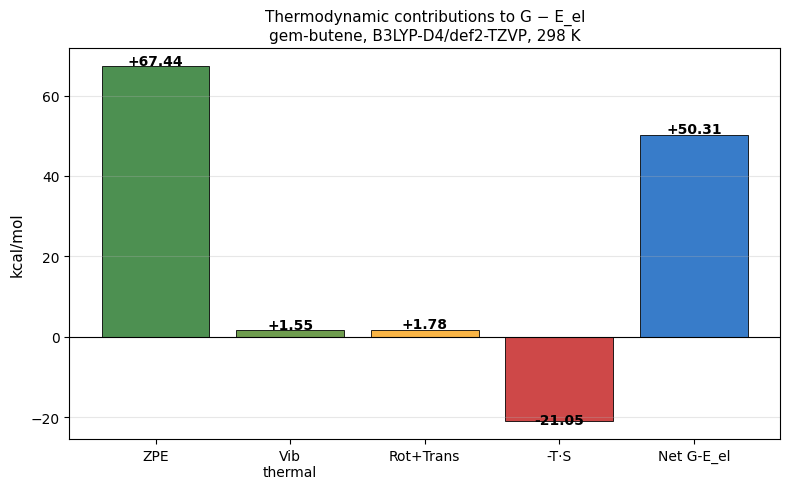

In [48]:
d = parse_thermo('gem-butene.out')

# ── Your task: fill in each value in kcal/mol ─────────────────────────────────

zpe_kcal        = data["zpe"] * EH_TO_KCAL # YOUR CODE: ZPE in kcal/mol
vib_thermal_kcal = data["vib_corr"] * EH_TO_KCAL # YOUR CODE: thermal vibrational correction in kcal/mol
rot_trans_kcal   = (data["rot_corr"] + data["trans_corr"]) * EH_TO_KCAL # YOUR CODE: rotational + translational correction in kcal/mol (combined)
entropy_kcal     = (data["s_vib"] + data["s_trans"] + data["s_rot"]) * EH_TO_KCAL # YOUR CODE: total T·S term in kcal/mol (vibrational + rotational + translational)
g_correction     = data["G_minus_Eel"] * EH_TO_KCAL # YOUR CODE: net G - E_el in kcal/mol (should match G_minus_Eel)

labels = ['ZPE', 'Vib\nthermal', 'Rot+Trans', '-T·S', 'Net G-E_el']
values = [zpe_kcal, vib_thermal_kcal, rot_trans_kcal, -entropy_kcal, g_correction]
colors = ['#2E7D32', '#558B2F', '#F9A825', '#C62828', '#1565C0']

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(labels, values, color=colors, edgecolor='black', linewidth=0.7, alpha=0.85)
for bar, val in zip(bars, values):
    ax.text(bar.get_x() + bar.get_width()/2,
            val + (0.3 if val >= 0 else -0.6),
            f'{val:+.2f}', ha='center', fontsize=10, fontweight='bold')
ax.axhline(0, color='black', linewidth=0.8)
ax.set_ylabel('kcal/mol', fontsize=11)
ax.set_title('Thermodynamic contributions to G − E_el\ngem-butene, B3LYP-D4/def2-TZVP, 298 K', fontsize=11)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

In [49]:
# Tests
d = parse_thermo('gem-butene.out')

# Verify the magnitudes make physical sense
zpe_kcal   = d['zpe'] * EH_TO_KCAL
s_tot_kcal = (d['s_vib'] + d['s_rot'] + d['s_trans']) * EH_TO_KCAL
g_minus_e  = d['G_minus_Eel'] * EH_TO_KCAL

assert 40 < zpe_kcal < 120,   f"ZPE should be 40-120 kcal/mol for C4H8, got {zpe_kcal:.1f}"
assert 10 < s_tot_kcal < 40,  f"T*S should be 10-40 kcal/mol at 298K, got {s_tot_kcal:.1f}"
assert s_tot_kcal > zpe_kcal * 0.1, "Entropy term should be significant"

# Translational entropy should dominate
s_trans_kcal = d['s_trans'] * EH_TO_KCAL
s_vib_kcal   = d['s_vib'] * EH_TO_KCAL
assert s_trans_kcal > s_vib_kcal, "Translational entropy should dominate vibrational"

print("Energy decomposition (gem-butene, kcal/mol):")
print(f"  ZPE             = +{zpe_kcal:.2f}")
print(f"  T·S(trans)      = -{d['s_trans']*EH_TO_KCAL:.2f}  (largest entropy term)")
print(f"  T·S(rot)        = -{d['s_rot']*EH_TO_KCAL:.2f}")
print(f"  T·S(vib)        = -{d['s_vib']*EH_TO_KCAL:.2f}")
print(f"  Net G-E(el)     = +{g_minus_e:.2f}")
print("Magnitudes are physically reasonable")
print("  Note: translational entropy >> vibrational entropy (3 continuous DOF vs discrete modes)")


Energy decomposition (gem-butene, kcal/mol):
  ZPE             = +67.44
  T·S(trans)      = -11.33  (largest entropy term)
  T·S(rot)        = -7.25
  T·S(vib)        = -2.47
  Net G-E(el)     = +50.31
Magnitudes are physically reasonable
  Note: translational entropy >> vibrational entropy (3 continuous DOF vs discrete modes)


---
# Part 5: Isomer Stability and Comparison to Experiment

---

### Exercise 5.1 — Relative Free Energies and Experimental Validation

Parse all three isomers and compute ΔG relative to *gem*-butene in kJ/mol:

| Quantity | Description |
|----------|-------------|
| `dg_trans` | ΔG(*trans* − *gem*) in kJ/mol |
| `dg_cis` | ΔG(*cis* − *gem*) in kJ/mol |

Experimental values (NIST, 298 K):
- Δ*G*(*trans* − *gem*) = **+6.2 kJ/mol**
- Δ*G*(*cis* − *gem*) = **+7.8 kJ/mol**

The plotting code is provided — once your numbers are correct, both panels will appear.

Then answer the following questions in the markdown cell below:

**Q1.** B3LYP-D4/def2-TZVP gets the ordering right but underestimates the gaps.
What physical effects might be missing from this DFT calculation?

**Q2.** All three molecules have the formula C₄H₈. If you had used only E_el
(no thermal corrections), would you still get the right ordering? Check by
computing ΔE_el for each isomer and comparing to ΔG.

In [50]:
d_gem   = parse_thermo('gem-butene.out')
d_trans = parse_thermo('trans-butene.out')
d_cis   = parse_thermo('cis-butene.out')

exp_trans = 6.2   # kJ/mol
exp_cis   = 7.8   # kJ/mol

dg_trans = (d_trans["G"] - d_gem["G"]) * EH_TO_KJ 
dg_cis   = (d_cis["G"] - d_gem["G"]) * EH_TO_KJ

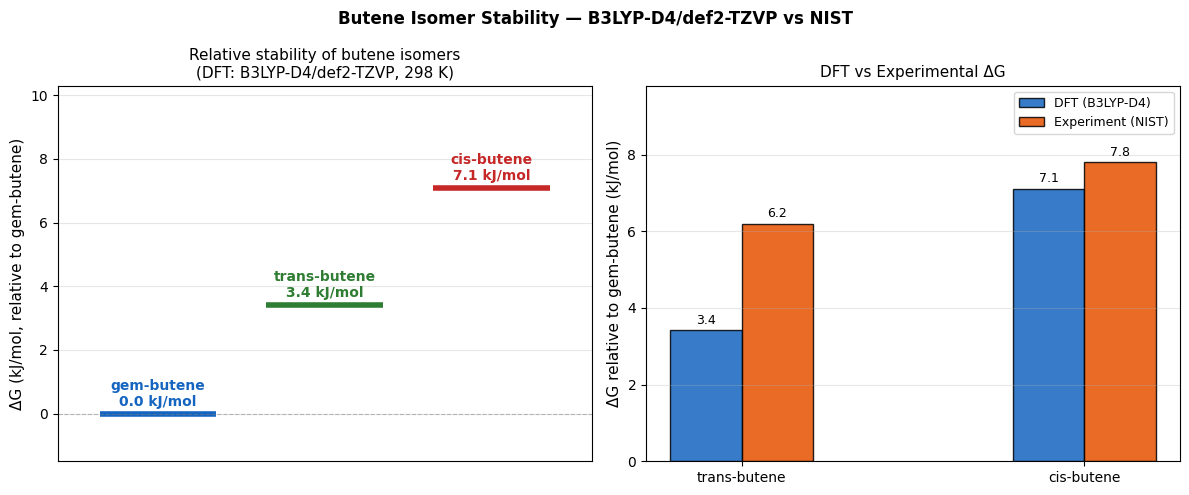


Isomer           DFT ΔG     Exp ΔG      Error
--------------------------------------------
gem                 0.0        0.0          —
trans              3.42        6.2      -2.78
cis                7.10        7.8      -0.70
(all values in kJ/mol)


In [51]:
# ==== Plotting previous cell =====

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Energy levels
isomers  = ['gem', 'trans', 'cis']
dg_vals  = [0.0, dg_trans, dg_cis]
colors   = ['#1565C0', '#2E7D32', '#C62828']

for x, name, dg, col in zip([1, 2, 3], isomers, dg_vals, colors):
    ax1.hlines(dg, x - 0.35, x + 0.35, colors=col, linewidth=4)
    ax1.text(x, dg + 0.15, f'{name}-butene\n{dg:.1f} kJ/mol',
             ha='center', va='bottom', fontsize=10, color=col, fontweight='bold')

ax1.set_xlim(0.4, 3.6)
ax1.set_ylim(-1.5, max(dg_cis, exp_cis) + 2.5)
ax1.set_xticks([])
ax1.set_ylabel('ΔG (kJ/mol, relative to gem-butene)', fontsize=11)
ax1.set_title('Relative stability of butene isomers\n(DFT: B3LYP-D4/def2-TZVP, 298 K)', fontsize=11)
ax1.axhline(0, color='grey', linewidth=0.8, linestyle='--', alpha=0.5)
ax1.grid(axis='y', alpha=0.3)

# DFT vs Experiment
x   = np.array([0.8, 2.0])
w   = 0.25

bars_dft = ax2.bar(x - w/2, [dg_trans, dg_cis], width=w,
                   label='DFT (B3LYP-D4)', color='#1565C0', alpha=0.85, edgecolor='black')
bars_exp = ax2.bar(x + w/2, [exp_trans, exp_cis], width=w,
                   label='Experiment (NIST)', color='#E65100', alpha=0.85, edgecolor='black')

for bar, val in zip(bars_dft, [dg_trans, dg_cis]):
    ax2.text(bar.get_x() + bar.get_width()/2, val + 0.1, f'{val:.1f}',
             ha='center', va='bottom', fontsize=9)
for bar, val in zip(bars_exp, [exp_trans, exp_cis]):
    ax2.text(bar.get_x() + bar.get_width()/2, val + 0.1, f'{val:.1f}',
             ha='center', va='bottom', fontsize=9)

ax2.set_xticks(x)
ax2.set_xticklabels(['trans-butene', 'cis-butene'], fontsize=10)
ax2.set_ylabel('ΔG relative to gem-butene (kJ/mol)', fontsize=11)
ax2.set_title('DFT vs Experimental ΔG', fontsize=11)
ax2.legend(fontsize=9)
ax2.set_ylim(0, max(exp_cis, dg_cis) + 2)
ax2.grid(axis='y', alpha=0.3)

plt.suptitle('Butene Isomer Stability — B3LYP-D4/def2-TZVP vs NIST', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

print(f"\n{'Isomer':<12} {'DFT ΔG':>10} {'Exp ΔG':>10} {'Error':>10}")
print("-" * 44)
print(f"{'gem':<12} {'0.0':>10} {'0.0':>10} {'—':>10}")
print(f"{'trans':<12} {dg_trans:>10.2f} {exp_trans:>10.1f} {dg_trans-exp_trans:>+10.2f}")
print(f"{'cis':<12} {dg_cis:>10.2f} {exp_cis:>10.1f} {dg_cis-exp_cis:>+10.2f}")
print("(all values in kJ/mol)")

In [52]:
# Tests
d_gem   = parse_thermo('gem-butene.out')
d_trans = parse_thermo('trans-butene.out')
d_cis   = parse_thermo('cis-butene.out')

dg_trans = (d_trans['G'] - d_gem['G']) * EH_TO_KJ
dg_cis   = (d_cis['G']   - d_gem['G']) * EH_TO_KJ

exp_trans, exp_cis = 6.2, 7.8

print("Relative free energies (kJ/mol, relative to gem-butene):")
print(f"  {'Isomer':<12} {'DFT':>8} {'Exp':>8} {'Error':>8}")
print(f"  {'-'*40}")
print(f"  {'gem':<12} {'0.0':>8} {'0.0':>8} {'—':>8}")
print(f"  {'trans':<12} {dg_trans:>8.2f} {exp_trans:>8.1f} {dg_trans-exp_trans:>+8.2f}")
print(f"  {'cis':<12} {dg_cis:>8.2f} {exp_cis:>8.1f} {dg_cis-exp_cis:>+8.2f}")

# Ordering must be correct
assert dg_trans > 0, "trans-butene should be less stable (ΔG > 0 relative to gem)"
assert dg_cis   > 0, "cis-butene should be less stable (ΔG > 0 relative to gem)"
assert dg_cis   > dg_trans, "cis should be less stable than trans"

# DFT should be in the right ballpark (within 5 kJ/mol of experiment)
assert abs(dg_trans - exp_trans) < 5,     f"DFT trans error too large: {dg_trans-exp_trans:.2f} kJ/mol"
assert abs(dg_cis - exp_cis) < 5,     f"DFT cis error too large: {dg_cis-exp_cis:.2f} kJ/mol"

print(f"\n Correct ordering: gem < trans < cis")
print(f" DFT errors within 5 kJ/mol of experiment")


Relative free energies (kJ/mol, relative to gem-butene):
  Isomer            DFT      Exp    Error
  ----------------------------------------
  gem               0.0      0.0        —
  trans            3.42      6.2    -2.78
  cis              7.10      7.8    -0.70

 Correct ordering: gem < trans < cis
 DFT errors within 5 kJ/mol of experiment


---
# Part 6: Decomposing ΔG into ΔH and TΔS

ΔG = ΔH − TΔS. These terms can work together or against each other, and understanding
which dominates tells you something about the physics of the stability difference.

---

### Exercise 6.1 — ΔH vs TΔS Contributions

For both *trans*- and *cis*-butene relative to *gem*-butene, compute:

| Quantity | Description |
|----------|-------------|
| `dH_trans`, `dH_cis` | ΔH in kJ/mol |
| `TdS_trans`, `TdS_cis` | TΔS in kJ/mol (note: T·S is already multiplied by T in the ORCA output) |
| `dG_trans`, `dG_cis` | ΔG = ΔH − TΔS — verify it matches your values from Exercise 5.1 |

The plotting code is provided — once your numbers are correct, the bar chart will appear.

Then think:

**Q1.** For isomers of the same molecular formula, you might expect ΔS ≈ 0.
Does your data support this? Which entropy component actually differs between isomers,
and why?

**Q2.** Is the stability ordering driven more by enthalpy or entropy differences?
What does this tell you about the physical origin of the isomer preference?

In [59]:
d_gem   = parse_thermo('gem-butene.out')
d_trans = parse_thermo('trans-butene.out')
d_cis   = parse_thermo('cis-butene.out')

dH_trans  = (d_trans["H"] -d_gem["H"])* EH_TO_KJ
dH_cis    = (d_cis["H"] -d_gem["H"])* EH_TO_KJ

s_g = d_gem["s_vib"] + d_gem["s_rot"] + d_gem["s_trans"]

TdS_trans = (d_trans['s_vib'] + d_trans["s_rot"] + d_trans["s_trans"] - s_g) * EH_TO_KJ
TdS_cis   = (d_cis['s_vib'] + d_cis["s_rot"] + d_cis["s_trans"] - s_g) * EH_TO_KJ

dG_trans  = dH_trans - TdS_trans
dG_cis    = dH_cis - TdS_cis 

# plotting code...

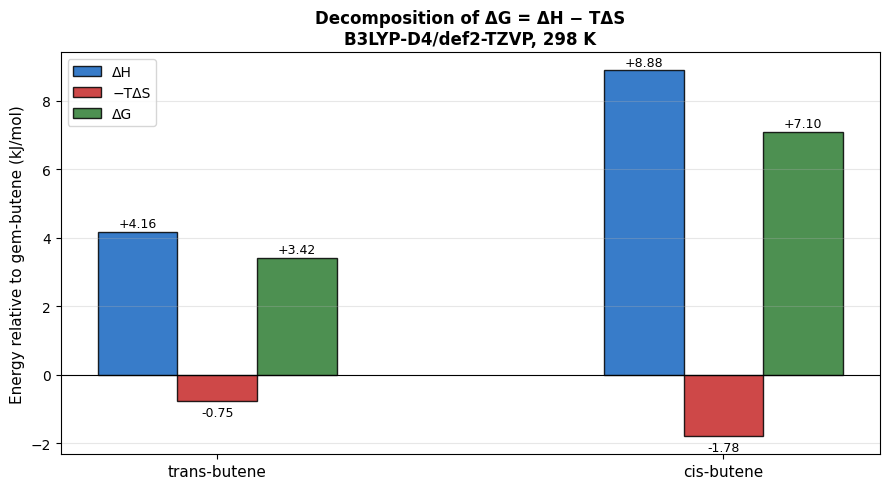


Isomer               ΔH        TΔS         ΔG  (kJ/mol)
----------------------------------------------
trans-butene     +4.164     +0.749     +3.416
cis-butene       +8.881     +1.784     +7.097


In [60]:
# ==== Plotting code ====
fig, ax = plt.subplots(figsize=(9, 5))

x      = np.array([0.8, 2.2])
w      = 0.22
labels = ['trans-butene', 'cis-butene']

dH_vals  = [dH_trans,  dH_cis]
TdS_vals = [TdS_trans, TdS_cis]
dG_vals  = [dG_trans,  dG_cis]

b1 = ax.bar(x - w, dH_vals,              width=w, label='ΔH',
            color='#1565C0', alpha=0.85, edgecolor='black')
b2 = ax.bar(x,     [-t for t in TdS_vals], width=w, label='−TΔS',
            color='#C62828', alpha=0.85, edgecolor='black')
b3 = ax.bar(x + w, dG_vals,              width=w, label='ΔG',
            color='#2E7D32', alpha=0.85, edgecolor='black')

for bars, vals in [(b1, dH_vals), (b2, [-t for t in TdS_vals]), (b3, dG_vals)]:
    for bar, val in zip(bars, vals):
        ypos = val + 0.05 if val >= 0 else val - 0.15
        ax.text(bar.get_x() + bar.get_width()/2, ypos, f'{val:+.2f}',
                ha='center', va='bottom' if val >= 0 else 'top', fontsize=9)

ax.axhline(0, color='black', linewidth=0.8)
ax.set_xticks(x)
ax.set_xticklabels(labels, fontsize=11)
ax.set_ylabel('Energy relative to gem-butene (kJ/mol)', fontsize=11)
ax.set_title('Decomposition of ΔG = ΔH − TΔS\nB3LYP-D4/def2-TZVP, 298 K',
             fontsize=12, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

print(f"\n{'Isomer':<12} {'ΔH':>10} {'TΔS':>10} {'ΔG':>10}  (kJ/mol)")
print("-" * 46)
for label, dH, TdS, dG in zip(labels, dH_vals, TdS_vals, dG_vals):
    print(f"{label:<12} {dH:>+10.3f} {TdS:>+10.3f} {dG:>+10.3f}")

---
# Part 7: Temperature Dependence of ΔG

ORCA can compute thermochemistry at multiple temperatures using `%FREQ TEMP 77, 298, 330, 450 END`.
The multi-temperature file `gem-butene-temps.out` contains all four.

---

### Exercise 7.1 — Write `parse_multi_temp(filename)`

The multi-temperature file contains several thermochemistry blocks, each starting with:
```
--------------------------
THERMOCHEMISTRY AT 298K
--------------------------
```

Write a function that:
1. Finds each `THERMOCHEMISTRY AT` block
2. Extracts the temperature from the header
3. Calls your existing `parse_thermo()` logic on that block
4. Returns a dict mapping temperature → thermochemistry dict

This is the hardest parsing exercise in the lab — the file has multiple blocks
with identical internal structure.

<details>
<summary>💡 Hint: splitting on temperature headers (click to expand)</summary>

```python
def parse_multi_temp(filename):
    with open(filename, 'r') as f:
        content = f.read()

    # Find all temperature headers and their positions
    header_pattern = r'THERMOCHEMISTRY AT (\d+(?:\.\d+)?)K'
    results = {}

    # Split content at each header
    parts = re.split(r'(THERMOCHEMISTRY AT \d+(?:\.\d+)?K)', content)
    # parts will be: [before, header1, block1, header2, block2, ...]

    for i, part in enumerate(parts):
        temp_match = re.match(r'THERMOCHEMISTRY AT (\d+(?:\.\d+)?)K', part)
        if temp_match and i + 1 < len(parts):
            T = float(temp_match.group(1))
            block = parts[i + 1]
            # Now extract values from this block using re.search on just this block
            results[T] = extract_from_block(block)

    return results
```
</details>

<details>
<summary>💡 Hint: reusing parse_thermo logic on a substring (click to expand)</summary>

Write a helper `_parse_block(content_str)` that takes a string (not a filename)
and runs the same regex patterns. Then both `parse_thermo()` and `parse_multi_temp()`
can call it.

```python
def _parse_block(content):
    """Extract thermochemistry values from a string containing one ORCA thermo block."""
    def extract(pattern):
        m = re.search(pattern, content)
        return float(m.group(1)) if m else None
    return {
        'e_el' : extract(r'FINAL SINGLE POINT ENERGY\s+(-?\d+\.\d+)'),
        # ... etc
    }
```
</details>

In [61]:
def parse_multi_temp(filename):
    """
    Parse thermochemistry at multiple temperatures from an ORCA 6.0 output file
    generated with %FREQ TEMP ... END.

    Parameters
    ----------
    filename : str

    Returns
    -------
    dict mapping float temperature (K) -> thermochemistry dict (same keys as parse_thermo)
    """
    with open(filename, 'r') as f:
        content = f.read()

    def extract_from_block(content):
        """Extract thermochemistry values from a string containing one ORCA thermo block."""
        def extract(pattern):
            m = re.search(pattern, content)
            return float(m.group(1)) if m else None
        return {
            "e_el" : extract(r"FINAL SINGLE POINT ENERGY\s+(-?\d+\.\d+)"),
            "zpe" : extract(r"Zero point energy\s+\.\.\.\s+(-?\d+\.\d+)"),
            "vib_corr" : extract(r"Thermal vibrational correction\s+\.\.\.\s+(-?\d+\.\d+)"),
            "rot_corr" :        extract(r"Thermal rotational correction\s+\.\.\.\s+(-?\d+\.\d+)"),
            "trans_corr" :      extract(r"Thermal translational correction\s+\.\.\.\s+(-?\d+\.\d+)"),
            "enthalpy_corr" :   extract(r"Thermal Enthalpy correction\s+\.\.\.\s+(-?\d+\.\d+)"),
            "s_vib" :           extract(r"Vibrational entropy\s+\.\.\.\s+(-?\d+\.\d+)"),
            "s_rot" :           extract(r"Rotational entropy\s+\.\.\.\s+(-?\d+\.\d+)"),
            "s_trans" :         extract(r"Translational entropy\s+\.\.\.\s+(-?\d+\.\d+)"),
            "H" :               extract(r"Total Enthalpy\s+\.\.\.\s+(-?\d+\.\d+)"),
            "G" :               extract(r"Final Gibbs free energy\s+\.\.\.\s+(-?\d+\.\d+)"),
            "G_minus_Eel" :     extract(r"G-E\(el\)\s+\.\.\.\s+(-?\d+\.\d+)")
        }

    # Find all temperature headers and their positions
    header_pattern = r'THERMOCHEMISTRY AT (\d+(?:\.\d+)?)K'
    results = {}

    # Split content at each header
    parts = re.split(r'(THERMOCHEMISTRY AT \d+(?:\.\d+)?K)', content)
    # parts will be: [before, header1, block1, header2, block2, ...]

    for i, part in enumerate(parts):
        temp_match = re.match(r'THERMOCHEMISTRY AT (\d+(?:\.\d+)?)K', part)
        if temp_match and i + 1 < len(parts):
            T = float(temp_match.group(1))
            block = parts[i + 1]
            # Now extract values from this block using re.search on just this block
            results[T] = extract_from_block(block)

    return results


# Test it
results = parse_multi_temp('gem_temps.out')
print(f"Temperatures found: {sorted(results.keys())} K")
print()
for T in sorted(results.keys()):
    d = results[T]
    print(f"  T = {T:5.0f} K:  G = {d['G']:.8f} Eh")


Temperatures found: [298.0, 330.0, 450.0] K

  T =   298 K:  G = -157.10595477 Eh
  T =   330 K:  G = -157.10960191 Eh
  T =   450 K:  G = -157.12423140 Eh


In [62]:
# Tests for parse_multi_temp()
results = parse_multi_temp('gem_temps.out')

assert isinstance(results, dict), "parse_multi_temp should return a dict"
assert len(results) >= 3, f"Expected at least 3 temperature blocks, found {len(results)}"

temps = sorted(results.keys())
print(f"Temperatures parsed: {temps} K")

for T in temps:
    d = results[T]
    assert 'G' in d, f"Missing 'G' key at T={T}"
    assert 'H' in d, f"Missing 'H' key at T={T}"
    assert d['H'] > d['G'], f"H > G failed at T={T}"

# G should decrease (become more negative) at higher T due to −T·S term
g_values = [results[T]['G'] for T in temps]
# At higher T, entropy penalty is larger so G should decrease
assert g_values[-1] < g_values[0],     f"G should decrease with T (entropy penalty grows): {g_values}"

print("\n✓ Multi-temperature parsing correct")
print(f"  G decreases with T: {g_values[0]:.6f} → {g_values[-1]:.6f} Eh")
print(f"  (Higher T means larger -T·S penalty — G becomes more negative)")


Temperatures parsed: [298.0, 330.0, 450.0] K

✓ Multi-temperature parsing correct
  G decreases with T: -157.105955 → -157.124231 Eh
  (Higher T means larger -T·S penalty — G becomes more negative)


---

### Exercise 7.2 — Plot G(T) and Discuss the Entropy

Using the multi-temperature data, create a **2-panel figure**:

- **Left panel:** G vs T for gem-butene (absolute values in Eh)
  — annotate the T = 298 K point
- **Right panel:** The thermal correction G-E(el) vs T in kcal/mol
  — this isolates the purely thermal contribution, independent of the electronic energy

Print the value of G-E(el) at each temperature.

**Think:** G-E(el) grows in magnitude as T increases. Which term drives this?
At very high temperatures, would you expect G to go to +∞ or −∞? Why?


In [65]:
# YOUR CODE HERE

results = parse_multi_temp('gem_temps.out')
temps = sorted(results.keys())



In [66]:
# Tests
results = parse_multi_temp('gem-butene-temps.out')
temps = sorted(results.keys())

g_vals  = [results[T]['G'] for T in temps]
gme_vals = [results[T]['G_minus_Eel'] * EH_TO_KCAL for T in temps]

assert all(g_vals[i] < g_vals[i-1] for i in range(1, len(g_vals))),     "G should decrease monotonically with T"

print("G and G-E(el) at each temperature:")
for T, g, gme in zip(temps, g_vals, gme_vals):
    print(f"  T = {T:5.0f} K:  G = {g:.6f} Eh    G-E(el) = {gme:.2f} kcal/mol")

print("\n G decreases with T (-T*S term dominates)")
print("  The entropy term grows linearly with T, making G more negative at high T")


FileNotFoundError: [Errno 2] No such file or directory: 'gem-butene-temps.out'

---
## Expanding

**1. The Quasi-RRHO correction.** ORCA uses the "Quasi-RRHO" approximation (Head-Gordon &
Grimme) for low-frequency modes by default. Look at the very low frequency modes in the
vibrational frequency list. For butene these are torsional modes around 108 cm-1.
In the standard harmonic oscillator, these modes contribute very large entropy at room
temperature. The Quasi-RRHO approximation dampens this contribution for modes below
~100 cm-1. Try computing the entropy contribution of mode 6 (108 cm-1) manually
using the formula from the preamble:

$$S_{v,K} = R\left[\frac{\Theta_{v,K}/T}{e^{\Theta_{v,K}/T}-1} - \ln(1-e^{-\Theta_{v,K}/T})\right]$$

where $\Theta_{v,K} = h\nu_K/k_B$.

**2. Higher-level single points.** The Neese tutorial describes using DLPNO-CCSD(T) for the
electronic energy and DFT for the thermal corrections:
$$G = E_{el}^{\text{CCSD(T)}} + (G - E_{el})^{\text{DFT}}$$
The CCSD(T) energies for the butene isomers are approximately:
- gem: −157.58234567 Eh
- trans: −157.58156789 Eh
- cis: −157.58092345 Eh

Use these with the DFT `G-E(el)` corrections you already parsed to compute improved ΔG values.
How do they compare to experiment? To the pure DFT result?


In [ ]:
import numpy as np

h  = 6.626e-34    # J*s
c  = 2.998e10     # cm/s
kB = 1.381e-23    # J/K
R  = 8.314        # J/(mol*K)
T  = 298.15       # K

nu_cm = 108.34    # cm-1 (mode 6 of gem-butene)
nu_Hz = nu_cm * c
Theta_v = h * nu_Hz / kB   # vibrational temperature in K

print(f"Characteristic vibrational temperature: Θv = {Theta_v:.1f} K")
print(f"At T = {T} K: Θv/T = {Theta_v/T:.3f}")

# YOUR ENTROPY CALCULATION HERE
# Sv = R * [...]


---
#  Summary

- **G = E_el + ZPE + thermal corrections − T·S.** The ZPE and entropy terms are not negligible.
  They can shift relative stability by several kJ/mol even for constitutional isomers
- **Statistical mechanics connects quantum frequencies to thermodynamics.** Each vibrational
  mode contributes to S and U through its partition function; lower-frequency modes contribute
  more entropy at a given temperature
- **Translational entropy is the largest T*S contributor** (~11 kcal/mol at 298 K) but is
  the same for all isomers of a given formula — the *differences* come from rotational and
  vibrational entropy
- **G-E(el)** is a transferable thermal correction: DFT computes it cheaply, and it can be
  combined with a high-level CCSD(T) electronic energy for accurate ΔG predictions
- **Parsing ORCA output** is a practical skill — the file is structured text and regex
  extracts every thermodynamic quantity in ~10 lines of code
